# Drive Direction Recognition (DDR) Algorithm — Explained

**Author:** Venay Chawda — Software Architect, ex-Bosch Global Software (Function Owner, DDR)  
**Package:** `vehicle-ddr` · [github.com/venaychawda/ddr-algorithm](https://github.com/venaychawda/ddr-algorithm)

---

This notebook is a visual, step-by-step walkthrough of the DDR algorithm.  
It is designed to be read **top-to-bottom** — each section builds on the previous one.

### What you will learn
1. Why DDR is a safety-critical function in ESP/VDC systems
2. The five processing layers of the algorithm
3. How each edge case is detected and handled
4. How to run the algorithm on your own signal data

### Prerequisites
```bash
pip install vehicle-ddr[viz]
pip install matplotlib numpy
```


---
## 1. Why Does Drive Direction Recognition Matter?

Drive Direction Recognition determines whether a vehicle is moving **forward**, **reverse**, or is at **standstill** — every 10 milliseconds.

This sounds simple. It is not. Here is why it is safety-critical:

| Downstream system | What it needs DDR for | Failure consequence |
|---|---|---|
| **ESP / ESC** | Applies brake torque in direction-dependent way during yaw intervention | Wrong direction → destabilises vehicle |
| **HSA** (Hill Start Assist) | Applies brake hold in the correct direction on a slope | Wrong direction → vehicle rolls downhill |
| **APA** (Automated Parking Assist) | Steering direction depends on forward/reverse | Wrong direction → collision |
| **PRND display & shift interlock** | Validates safe state before allowing gear change | False standstill → unsafe gear engagement |

Under **ISO 26262**, DDR in an ESP system is typically classified **ASIL-B or ASIL-C** depending on vehicle architecture.

### The core challenge: wheel speed sensors are direction-blind

ABS wheel speed sensors (reluctance type or Hall effect) output a **pulse frequency proportional to speed magnitude**.  
They cannot distinguish a wheel rotating forward from one rotating backward.  
Direction must be **inferred** by fusing multiple signals.


In [1]:
# Setup — import everything we need for this notebook
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for dark, clean plots
plt.rcParams.update({
    'figure.facecolor': '#0d0d10',
    'axes.facecolor': '#16161a',
    'axes.edgecolor': '#333',
    'axes.labelcolor': '#e4e2db',
    'xtick.color': '#7a7870',
    'ytick.color': '#7a7870',
    'text.color': '#e4e2db',
    'grid.color': '#2a2a30',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'lines.linewidth': 1.8,
    'font.family': 'sans-serif',
    'figure.dpi': 110,
})

from ddr_algorithm import DDREngine, VehicleSignals, WheelSpeeds, GearPosition, DriveDirection
from ddr_algorithm.simulation.vehicle_model import (
    VehicleModel, manoeuvre_city_drive, manoeuvre_reverse_parking,
    manoeuvre_hill_start, manoeuvre_k_turn, manoeuvre_abs_stop, ManoeuvrePoint
)
from ddr_algorithm.simulation.scenario_generator import ScenarioGenerator, get_all_scenarios
from ddr_algorithm.core.diagnostics import SessionSummary, iter_diagnostic_events

# Colour palette
DIR_COLOR = {
    DriveDirection.FORWARD:    '#1D9E75',
    DriveDirection.REVERSE:    '#D4900A',
    DriveDirection.STANDSTILL: '#7a7870',
    DriveDirection.UNKNOWN:    '#D85A30',
}
DIR_LABEL_COLOR = {
    DriveDirection.FORWARD:    '#9FE1CB',
    DriveDirection.REVERSE:    '#FAC775',
    DriveDirection.STANDSTILL: '#aaa',
    DriveDirection.UNKNOWN:    '#F5C4B3',
}

print("✅ Imports OK — DDR algorithm ready")


✅ Imports OK — DDR algorithm ready


---
## 2. Algorithm Architecture — Five Layers

The DDR algorithm is structured as a **five-layer pipeline**, each layer in its own module.  
Data flows top-to-bottom at every 10ms cycle.

```
Raw sensors (100 Hz)
       │
       ▼
┌──────────────────────────────────────────┐
│  Layer 1: Signal Processor               │
│  signal_processor.py                     │
│  • IIR low-pass filter (α=0.3)           │
│  • Outlier rejection: peer-mean compare  │
│  • Sensor health tracker (persistence=5) │
└──────────────────────┬───────────────────┘
                       │
                       ▼
┌──────────────────────────────────────────┐
│  Layer 2: Plausibility Engine            │
│  plausibility.py                         │
│  • 6 cross-signal checks                 │
│  • Weighted vote aggregation             │
│  • Neutral rollback detection            │
└──────────────────────┬───────────────────┘
                       │
                       ▼
┌──────────────────────────────────────────┐
│  Layer 3: State Machine (FSM)            │
│  state_machine.py                        │
│  • States: FWD / REV / STANDSTILL        │
│  • 200ms debounce on direction change    │
│  • Hysteresis at standstill boundary     │
└──────────────────────┬───────────────────┘
                       │
                       ▼
┌──────────────────────────────────────────┐
│  Layer 4: Confidence Scorer              │
│  confidence.py                           │
│  • Composite 0–100% metric               │
│  • Speed, health, time-in-state, votes   │
└──────────────────────┬───────────────────┘
                       │
                       ▼
┌──────────────────────────────────────────┐
│  Layer 5: Diagnostics                    │
│  diagnostics.py                          │
│  • 8-bit diagnostic word (CAN-encodable) │
│  • Session summary + event log           │
└──────────────────────┬───────────────────┘
                       │
                       ▼
           DDROutput(direction, confidence, diagnostics)
```


---
## 3. Layer 1 — Signal Processor

### IIR Low-Pass Filter

Raw wheel speed signals from ABS sensors are noisy at ~100 Hz.  
We apply a first-order IIR (Infinite Impulse Response) filter:

> **y[n] = α · x[n] + (1 − α) · y[n−1]**

Where **α = 0.3** gives a ~33ms time constant — enough to smooth sensor noise while preserving dynamic response.


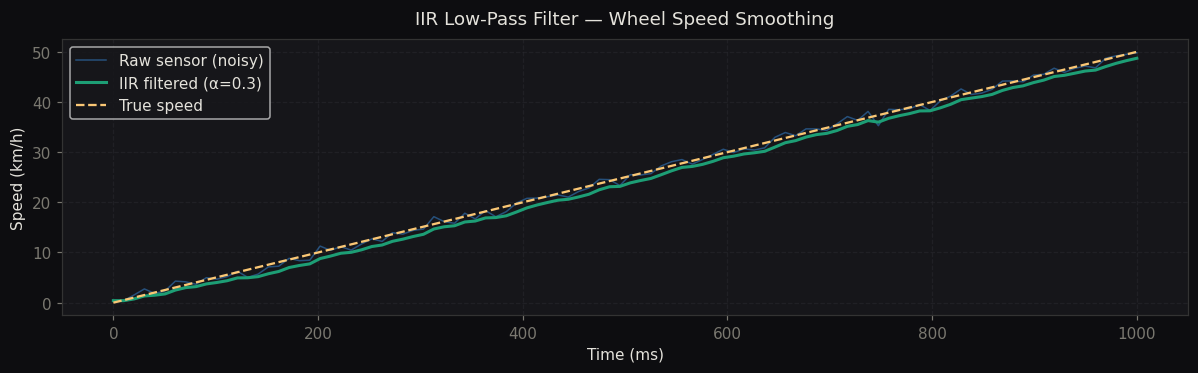

RMS noise (raw):      0.723 km/h
RMS noise (filtered): 0.390 km/h
Noise reduction:      46%


In [ ]:
# ── Visualise IIR filter effect ───────────────────────────────────────────────
np.random.seed(42)
t = np.linspace(0, 1.0, 100)  # 1 second, 100 samples (10ms each)

# True speed: ramp from 0 to 50 km/h
true_speed = 50.0 * t

# Add realistic sensor noise
raw_speed = true_speed + np.random.normal(0, 0.8, len(t))

# Apply IIR filter
alpha = 0.3
filtered = np.zeros_like(raw_speed)
filtered[0] = raw_speed[0]
for i in range(1, len(raw_speed)):
    filtered[i] = alpha * raw_speed[i] + (1 - alpha) * filtered[i - 1]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t * 1000, raw_speed,   color='#378ADD', alpha=0.5, linewidth=1, label='Raw sensor (noisy)')
ax.plot(t * 1000, filtered,    color='#1D9E75', linewidth=2,             label='IIR filtered (α=0.3)')
ax.plot(t * 1000, true_speed,  color='#FAC775', linewidth=1.5, linestyle='--', label='True speed')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Speed (km/h)')
ax.set_title('IIR Low-Pass Filter — Wheel Speed Smoothing', pad=10)
ax.legend(loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()
print(f"RMS noise (raw):      {np.std(raw_speed - true_speed):.3f} km/h")
print(f"RMS noise (filtered): {np.std(filtered - true_speed):.3f} km/h")
print(f"Noise reduction:      {(1 - np.std(filtered-true_speed)/np.std(raw_speed-true_speed))*100:.0f}%")


### Outlier Rejection — Wheel Sensor Fault Detection

If one wheel speed sensor fails (e.g. stuck at zero), the algorithm must detect it  
without disabling the whole DDR output.

**Method:** Compare each wheel against the mean of the other three.  
If deviation exceeds **8 km/h** for **5 consecutive cycles** → sensor flagged as FAULT.


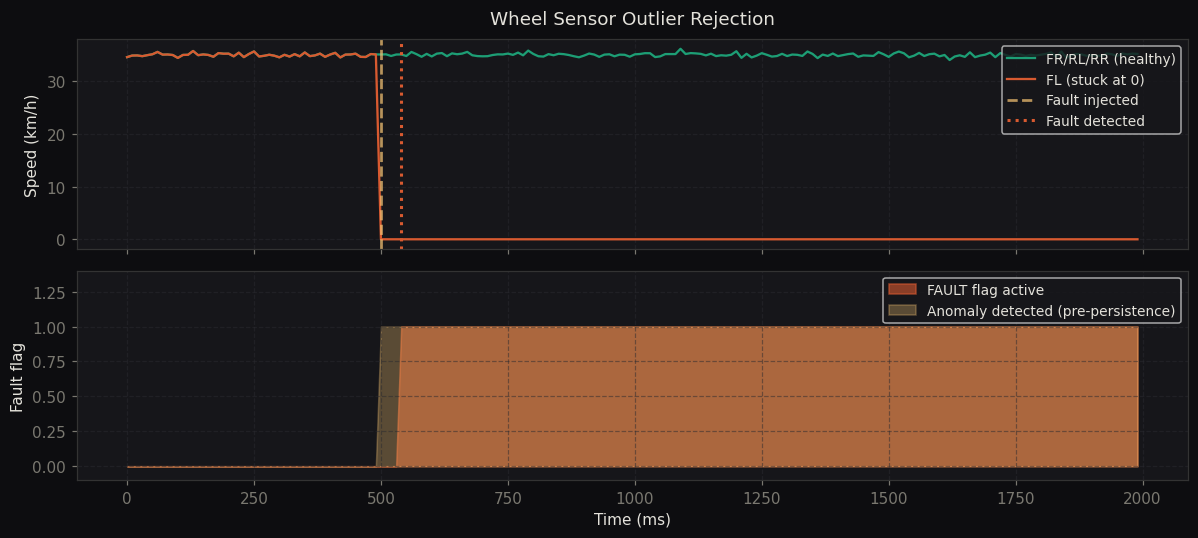

Fault injected at:  500 ms
Fault detected at:  540 ms
Detection latency:  40 ms (4 cycles × 5-cycle persistence)


In [ ]:
# ── Visualise outlier rejection ────────────────────────────────────────────────
t_ms = np.arange(0, 2000, 10)  # 2 seconds
normal_speed = 35.0 + np.random.normal(0, 0.3, len(t_ms))
fl_speed = normal_speed.copy()
fl_speed[50:] = 0.0  # FL sensor stuck at 0 after 500ms

threshold = 8.0
peer_mean = normal_speed  # Other 3 wheels all at ~35 km/h
fault_detected = np.abs(fl_speed - peer_mean) > threshold

# Persistence: only flag after 5 consecutive anomalies
fault_persistent = np.zeros(len(t_ms), dtype=bool)
count = 0
for i, f in enumerate(fault_detected):
    count = count + 1 if f else 0
    fault_persistent[i] = count >= 5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

ax1.plot(t_ms, normal_speed, color='#1D9E75', label='FR/RL/RR (healthy)', linewidth=1.5)
ax1.plot(t_ms, fl_speed,     color='#D85A30', label='FL (stuck at 0)', linewidth=1.5)
ax1.axvline(500, color='#FAC775', linestyle='--', alpha=0.7, label='Fault injected')
ax1.axvline(t_ms[np.argmax(fault_persistent)], color='#D85A30', linestyle=':', linewidth=2, label='Fault detected')
ax1.set_ylabel('Speed (km/h)')
ax1.set_title('Wheel Sensor Outlier Rejection', pad=10)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True)

ax2.fill_between(t_ms, fault_persistent.astype(float), color='#D85A30', alpha=0.6, label='FAULT flag active')
ax2.fill_between(t_ms, fault_detected.astype(float), color='#FAC775', alpha=0.3, label='Anomaly detected (pre-persistence)')
ax2.set_ylabel('Fault flag')
ax2.set_xlabel('Time (ms)')
ax2.set_ylim(-0.1, 1.4)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.show()
detection_ms = t_ms[np.argmax(fault_persistent)]
print(f"Fault injected at:  500 ms")
print(f"Fault detected at:  {detection_ms} ms")
print(f"Detection latency:  {detection_ms - 500} ms ({(detection_ms-500)//10:.0f} cycles × 5-cycle persistence)")


---
## 4. Layer 2 — Plausibility Engine

The plausibility engine runs **6 independent cross-signal checks** per cycle,  
each producing a weighted vote for a direction.

| Check | Signals used | Key insight |
|---|---|---|
| `gear_position` | Gear CAN signal | Primary at low speed; weight 0.6 |
| `longitudinal_acc` | Accelerometer | Positive acc → FORWARD vote only |
| `speed_magnitude` | Wheel speeds + brake | Zero speed + brake → STANDSTILL |
| `gear_speed_cross` | Gear + speed + acc | Detects stale gear CAN message |
| `neutral_rollback` | Gear=N + acc<0 + speed>0 | Detects hill rollback without gear |
| `brake_acc` | Brake + speed | High brake + zero speed → STANDSTILL |

### Vote Aggregation


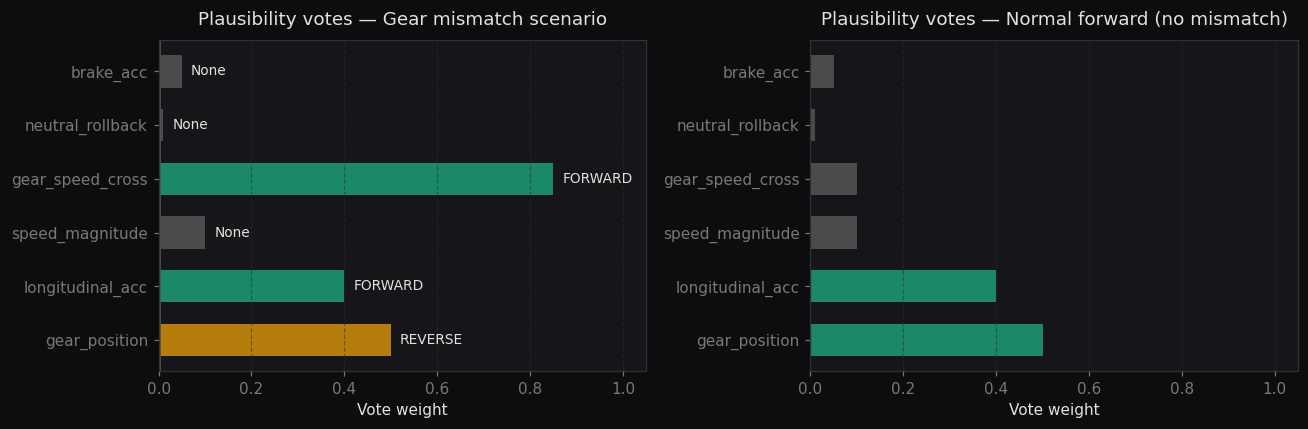

Gear mismatch scenario → FORWARD  confidence=98%
  gear_mismatch flag: True
Normal forward      → FORWARD  confidence=100%


In [ ]:
# ── Visualise vote weights across a gear mismatch scenario ───────────────────
from ddr_algorithm.core.plausibility import PlausibilityEngine, aggregate_votes
from ddr_algorithm.core.signal_processor import SignalProcessor

# Scenario: vehicle at 20 km/h forward but gear=REVERSE (stale CAN)
sig_mismatch = VehicleSignals(
    timestamp_ms=0,
    wheel_speeds=WheelSpeeds(fl=20, fr=20, rl=20, rr=20),
    gear_position=GearPosition.REVERSE,
    longitudinal_acceleration=1.2,
    brake_pressure_bar=0,
)
processor = SignalProcessor()
plausibility = PlausibilityEngine()
from ddr_algorithm.models.vehicle_signals import DiagnosticWord

processed = processor.process(sig_mismatch)
votes, diag = plausibility.evaluate(sig_mismatch, processed)
winner, conf = aggregate_votes(votes)

# Plot vote weights
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sources = [v.source for v in votes]
weights = [v.weight for v in votes]
directions = [v.suggested_direction.value if v.suggested_direction else 'None' for v in votes]
colors = [DIR_COLOR.get(v.suggested_direction, '#555') if v.suggested_direction else '#555' for v in votes]

bars = ax1.barh(sources, weights, color=colors, alpha=0.85, height=0.6)
ax1.set_xlabel('Vote weight')
ax1.set_title('Plausibility votes — Gear mismatch scenario', pad=10)
ax1.axvline(0, color='#555')
ax1.set_xlim(0, 1.05)
for bar, d in zip(bars, directions):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             d, va='center', fontsize=9, color='#e4e2db')
ax1.grid(True, axis='x')

# Compare: same speed but gear=DRIVE (no mismatch)
sig_normal = VehicleSignals(
    timestamp_ms=0,
    wheel_speeds=WheelSpeeds(fl=20, fr=20, rl=20, rr=20),
    gear_position=GearPosition.DRIVE,
    longitudinal_acceleration=1.2,
    brake_pressure_bar=0,
)
proc2 = SignalProcessor()
votes2, _ = PlausibilityEngine().evaluate(sig_normal, proc2.process(sig_normal))
winner2, conf2 = aggregate_votes(votes2)

sources2 = [v.source for v in votes2]
weights2 = [v.weight for v in votes2]
colors2 = [DIR_COLOR.get(v.suggested_direction, '#555') if v.suggested_direction else '#555' for v in votes2]
ax2.barh(sources2, weights2, color=colors2, alpha=0.85, height=0.6)
ax2.set_xlabel('Vote weight')
ax2.set_title('Plausibility votes — Normal forward (no mismatch)', pad=10)
ax2.set_xlim(0, 1.05)
ax2.grid(True, axis='x')

plt.tight_layout()
plt.show()

print(f"Gear mismatch scenario → {winner.value}  confidence={conf:.0f}%")
print(f"  gear_mismatch flag: {diag.gear_mismatch}")
print(f"Normal forward      → {winner2.value}  confidence={conf2:.0f}%")


---
## 5. Layer 3 — Finite State Machine (FSM)

The FSM converts the noisy, per-cycle plausibility vote into a **stable direction output**.

### States

```
        ┌──────────────────────────────────────────┐
        │                                          │
        ▼                                          │
     INIT ──────────────────────────────► FORWARD ◄──────────────┐
                                             │                    │
                     ┌──────────────────────►│◄──────────────┐   │
                     │                       │               │   │
             TRANSITIONING_FWD ◄─────── STANDSTILL ─────► TRANSITIONING_REV
                                             │
                                             ▼
                                          REVERSE
```

### Key design choices:
- **Agree cycles = 3** — plausibility engine must vote the same direction for 3 consecutive cycles before FSM starts transitioning
- **Debounce = 200ms** — FSM holds in TRANSITIONING state for 200ms before committing
- **Standstill transition is immediate** — no debounce needed (standstill is unambiguous at zero speed)
- **Output during transition = UNKNOWN** — downstream systems must handle this gracefully


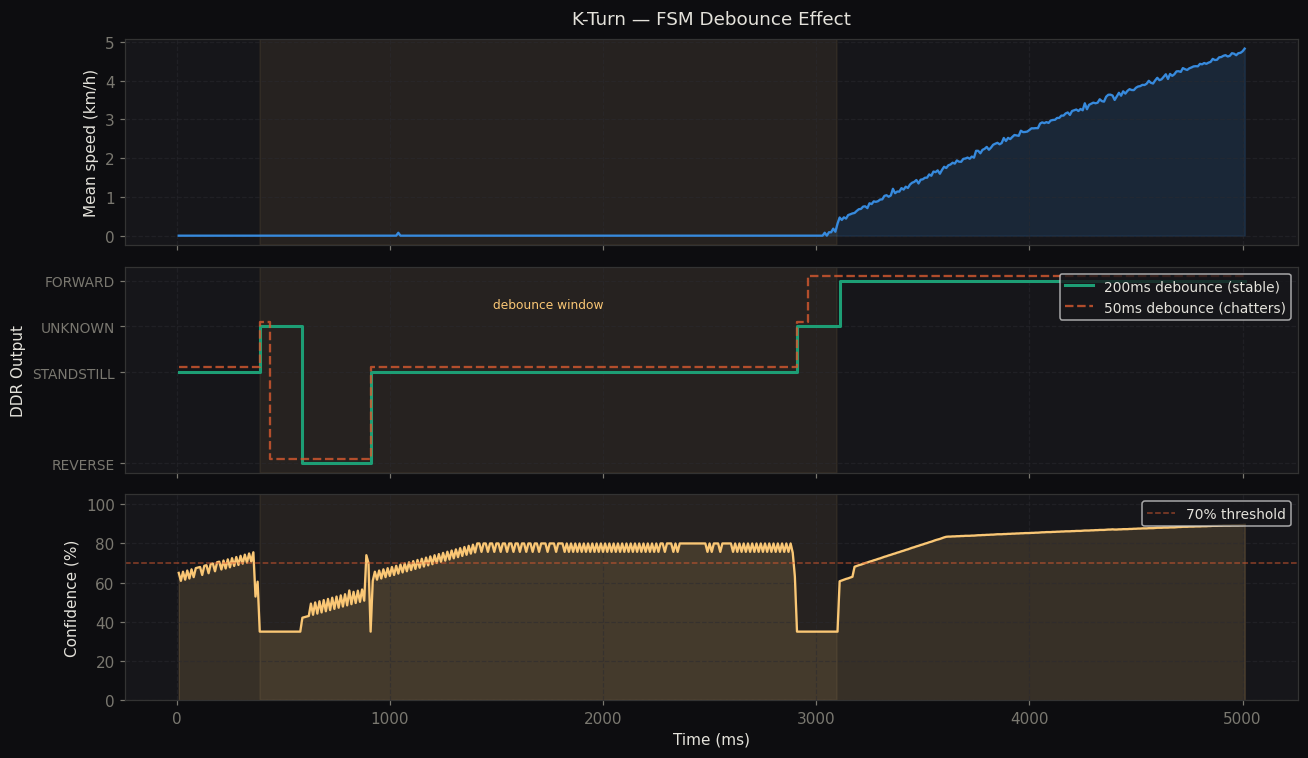

Transition active for: 410 ms
Chatter cycles (50ms): 5 direction changes
Chatter cycles (200ms): 5 direction changes


In [ ]:
# ── Visualise FSM debounce effect during K-turn ───────────────────────────────
model = VehicleModel(noise_seed=42)
signals = model.run_manoeuvre(manoeuvre_k_turn())

# Run with default 200ms debounce
engine_200 = DDREngine(debounce_ms=200)
outputs_200 = engine_200.process_batch(signals)

# Run with 50ms debounce (too aggressive — chatters)
engine_50 = DDREngine(debounce_ms=50)
outputs_50 = engine_50.process_batch(signals)

t_ms = [s.timestamp_ms for s in signals]
dir_num_200 = [{'FORWARD':2,'REVERSE':0,'STANDSTILL':1,'UNKNOWN':1.5}[o.direction.value] for o in outputs_200]
dir_num_50  = [{'FORWARD':2,'REVERSE':0,'STANDSTILL':1,'UNKNOWN':1.5}[o.direction.value] for o in outputs_50]
conf_200 = [o.confidence for o in outputs_200]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

# Speed
mean_speeds = [(s.wheel_speeds.fl + s.wheel_speeds.fr + s.wheel_speeds.rl + s.wheel_speeds.rr)/4 for s in signals]
axes[0].plot(t_ms, mean_speeds, color='#378ADD', linewidth=1.5)
axes[0].set_ylabel('Mean speed (km/h)')
axes[0].set_title('K-Turn — FSM Debounce Effect', pad=10)
axes[0].fill_between(t_ms, 0, mean_speeds, alpha=0.15, color='#378ADD')
axes[0].grid(True)

# Direction comparison
yticks = {0: 'REVERSE', 1: 'STANDSTILL', 1.5: 'UNKNOWN', 2: 'FORWARD'}
axes[1].step(t_ms, dir_num_200, color='#1D9E75', linewidth=2, where='post', label='200ms debounce (stable)')
axes[1].step(t_ms, [d + 0.05 for d in dir_num_50], color='#D85A30', linewidth=1.5, where='post',
             linestyle='--', label='50ms debounce (chatters)', alpha=0.8)
axes[1].set_yticks(list(yticks.keys()))
axes[1].set_yticklabels(list(yticks.values()), fontsize=9)
axes[1].set_ylabel('DDR Output')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True)

# Confidence
axes[2].plot(t_ms, conf_200, color='#FAC775', linewidth=1.5)
axes[2].fill_between(t_ms, 0, conf_200, alpha=0.15, color='#FAC775')
axes[2].axhline(70, color='#D85A30', linestyle='--', alpha=0.6, linewidth=1, label='70% threshold')
axes[2].set_ylabel('Confidence (%)')
axes[2].set_xlabel('Time (ms)')
axes[2].set_ylim(0, 105)
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(True)

# Highlight transition window
trans_active = [i for i, o in enumerate(outputs_200) if o.diagnostics.transition_active]
if trans_active:
    t_start = t_ms[trans_active[0]]
    t_end   = t_ms[trans_active[-1]]
    for ax in axes:
        ax.axvspan(t_start, t_end, alpha=0.07, color='#FAC775')
    axes[1].annotate('debounce window', xy=((t_start+t_end)/2, 1.7),
                     fontsize=8, color='#FAC775', ha='center')

plt.tight_layout()
plt.show()
print(f"Transition active for: {len(trans_active)*10} ms")
print(f"Chatter cycles (50ms): {sum(1 for a,b in zip(dir_num_50, dir_num_50[1:]) if a!=b)} direction changes")
print(f"Chatter cycles (200ms): {sum(1 for a,b in zip(dir_num_200, dir_num_200[1:]) if a!=b)} direction changes")


---
## 6. Layer 4 — Confidence Scorer

Confidence is a **composite metric** — not just the plausibility vote score:

| Component | Weight | Source |
|---|---|---|
| Vote agreement score | 50% | Plausibility engine output |
| Speed magnitude | 20% | Higher speed → more reliable wheel data |
| Sensor health | 15% | Fewer fault flags → higher confidence |
| Time in state | 15% | Ramp-up after entering a new stable state |

Penalties are applied multiplicatively:
- **Gear mismatch** → ×0.85
- **Plausibility conflict** → ×0.75  
- **Wheel fault** → ×0.90
- **Transition active** → capped at 35%


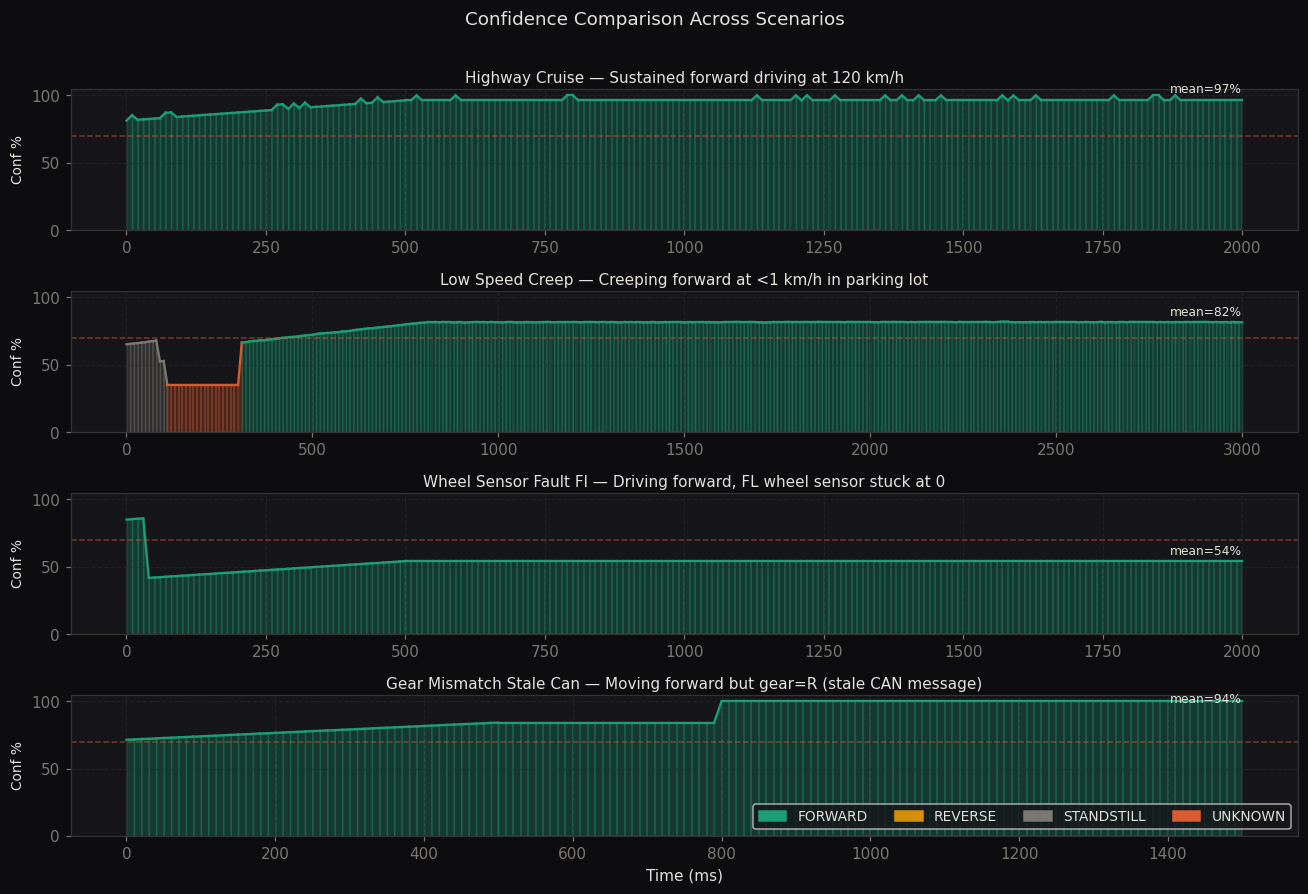

In [ ]:
# ── Compare confidence across scenarios ─────────────────────────────────────
scenarios_to_compare = ['highway_cruise', 'low_speed_creep', 'wheel_sensor_fault_fl', 'gear_mismatch_stale_can']
gen = ScenarioGenerator(seed=42)
all_scenarios = {s.name: s for s in get_all_scenarios()}

fig, axes = plt.subplots(len(scenarios_to_compare), 1, figsize=(12, 8), sharex=False)

for ax, sc_name in zip(axes, scenarios_to_compare):
    sc = all_scenarios[sc_name]
    signals = gen.generate(sc)
    engine = DDREngine()
    outputs = engine.process_batch(signals)

    t_ms = [s.timestamp_ms for s in signals]
    conf = [o.confidence for o in outputs]
    dirs = [o.direction for o in outputs]

    # Colour confidence line by direction
    for i in range(len(t_ms)-1):
        ax.fill_between(t_ms[i:i+2], 0, conf[i:i+2],
                        color=DIR_COLOR[dirs[i]], alpha=0.25)
        ax.plot(t_ms[i:i+2], conf[i:i+2], color=DIR_COLOR[dirs[i]], linewidth=1.5)

    ax.axhline(70, color='#D85A30', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_ylim(0, 105)
    ax.set_ylabel('Conf %', fontsize=9)
    ax.set_title(f'{sc_name.replace("_"," ").title()} — {sc.description}', fontsize=10, pad=4)
    ax.grid(True)

    mean_c = np.mean(conf[len(conf)//4:])  # settled mean
    ax.text(t_ms[-1], mean_c + 5, f'mean={mean_c:.0f}%', fontsize=8,
            color='#e4e2db', ha='right')

patches = [mpatches.Patch(color=c, label=d.value) for d, c in DIR_COLOR.items()]
axes[-1].legend(handles=patches, loc='lower right', fontsize=9, ncol=4)
axes[-1].set_xlabel('Time (ms)')

plt.suptitle('Confidence Comparison Across Scenarios', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
## 7. The 8 Critical Edge Cases

These are the scenarios that break naive DDR implementations.  
Each one is a real-world failure mode encountered in production VDC/ESP programmes.


In [ ]:
# ── Run all 8 edge cases and summarise ──────────────────────────────────────
edge_scenarios = [
    'gear_mismatch_stale_can',
    'hill_rollback_neutral',
    'standstill_traffic_light',
    'low_speed_creep',
    'wheel_sensor_fault_fl',
    'k_turn_transition',
    'abs_braking',
    'park_standstill',
]
gen = ScenarioGenerator(seed=42)
all_sc = {s.name: s for s in get_all_scenarios()}

results = []
for sc_name in edge_scenarios:
    sc = all_sc[sc_name]
    signals = gen.generate(sc)
    engine = DDREngine()
    outputs = engine.process_batch(signals)
    settled = outputs[int(len(outputs)*0.7):]
    from collections import Counter
    dominant = Counter(o.direction for o in settled).most_common(1)[0][0]
    mean_conf = np.mean([o.confidence for o in settled])
    summary = SessionSummary.from_outputs(outputs)
    results.append({
        'scenario': sc_name.replace('_', ' '),
        'expected': sc.expected_direction.value,
        'output':   dominant.value,
        'mean_conf_%': round(mean_conf, 1),
        'gear_mismatch_events': summary.gear_mismatch_events,
        'wheel_fault_events':   summary.wheel_fault_events,
        'transitions':          summary.transition_events,
        'pass': '✅' if dominant == sc.expected_direction else '⚠️'
    })

import pandas as pd
df = pd.DataFrame(results)
print(df.to_string(index=False))


                scenario   expected     output  mean_conf_%  gear_mismatch_events  wheel_fault_events  transitions pass
 gear mismatch stale can    FORWARD    FORWARD        100.0                     1                   0            0    ✅
   hill rollback neutral    REVERSE    REVERSE         78.0                     0                   0            1    ✅
standstill traffic light STANDSTILL STANDSTILL         80.2                     0                   0            0    ✅
         low speed creep    FORWARD    FORWARD         81.6                     0                   0            1    ✅
   wheel sensor fault fl    FORWARD    FORWARD         54.2                     0                   1            0    ✅
       k turn transition    UNKNOWN    FORWARD         56.8                     0                   0            2   ⚠️
             abs braking STANDSTILL STANDSTILL         78.4                     0                   0            1    ✅
         park standstill STANDSTILL STAN

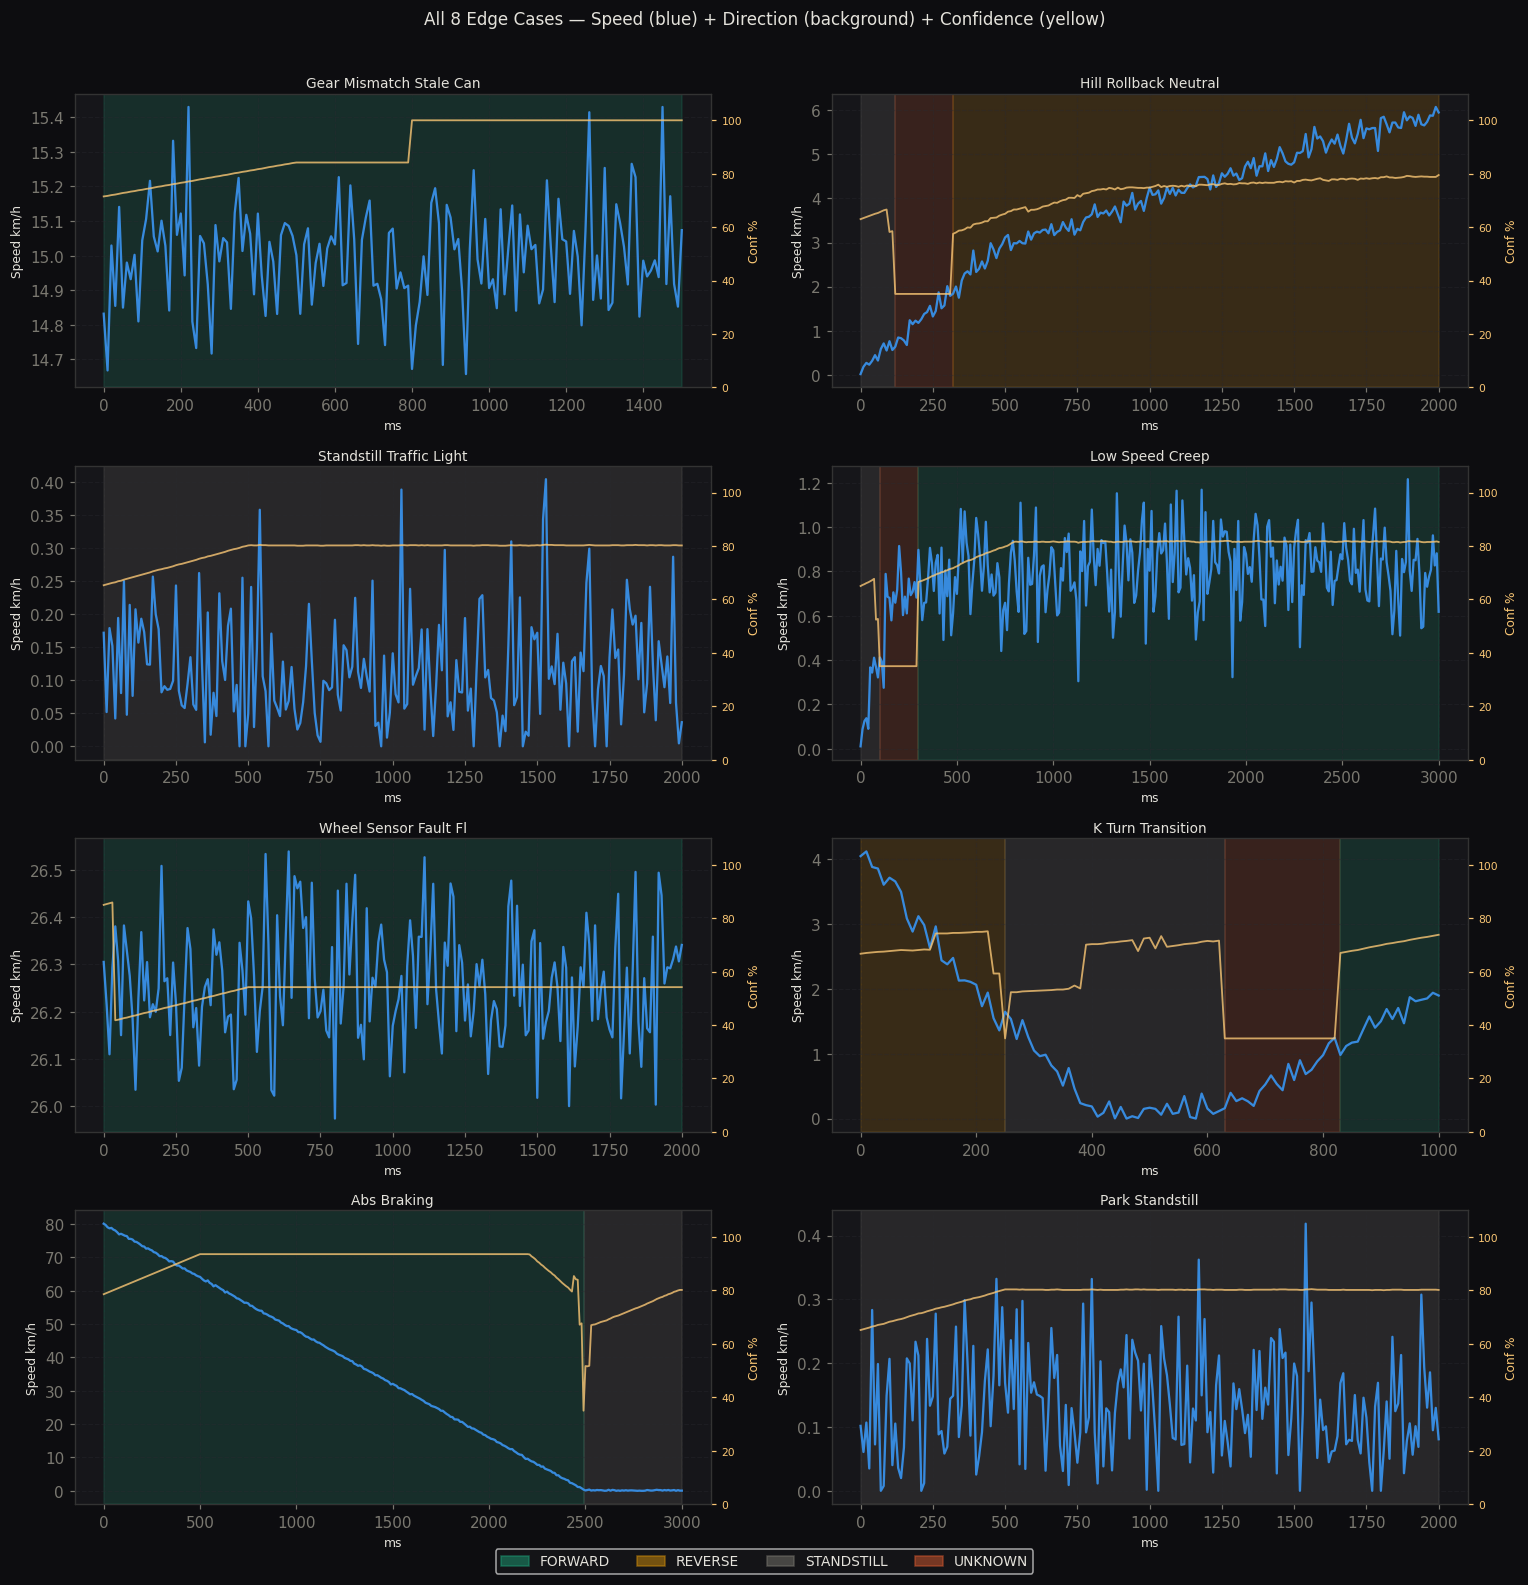

In [ ]:
# ── Visualise all 8 edge cases in one figure ─────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, sc_name in zip(axes, edge_scenarios):
    sc = all_sc[sc_name]
    signals = gen.generate(sc)
    engine = DDREngine()
    outputs = engine.process_batch(signals)

    t_ms   = [s.timestamp_ms for s in signals]
    conf   = [o.confidence for o in outputs]
    dirs   = [o.direction for o in outputs]
    speeds = [(s.wheel_speeds.fl+s.wheel_speeds.fr+s.wheel_speeds.rl+s.wheel_speeds.rr)/4 for s in signals]

    # Direction as coloured background
    prev_d, prev_t = dirs[0], t_ms[0]
    for i, (t, d) in enumerate(zip(t_ms[1:], dirs[1:]), 1):
        if d != prev_d or i == len(t_ms)-1:
            ax.axvspan(prev_t, t, alpha=0.18, color=DIR_COLOR[prev_d])
            prev_d, prev_t = d, t

    ax2 = ax.twinx()
    ax2.plot(t_ms, conf, color='#FAC775', linewidth=1.2, alpha=0.8)
    ax2.set_ylim(0, 110)
    ax2.set_ylabel('Conf %', fontsize=8, color='#FAC775')
    ax2.tick_params(axis='y', colors='#FAC775', labelsize=7)

    ax.plot(t_ms, speeds, color='#378ADD', linewidth=1.5)
    ax.set_title(sc_name.replace('_', ' ').title(), fontsize=9, pad=4)
    ax.set_xlabel('ms', fontsize=8)
    ax.set_ylabel('Speed km/h', fontsize=8)
    ax.grid(True, alpha=0.4)

# Legend
patches = [mpatches.Patch(color=c, alpha=0.5, label=d.value) for d, c in DIR_COLOR.items()]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.01))
plt.suptitle('All 8 Edge Cases — Speed (blue) + Direction (background) + Confidence (yellow)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


---
## 8. Full Drive Simulation — Vehicle Model

The kinematic vehicle model generates physically consistent sensor signals  
using Newton's second law integration at 10ms steps.

**Physical parameters (C-segment passenger car):**
- Mass: 1450 kg
- Drag coefficient: 0.30
- Rolling resistance: 0.012
- Brake model: 100 bar → ~0.95g deceleration
- Wheel speed noise: σ = 0.08 km/h per wheel
- Accelerometer bias: 0.02 m/s²


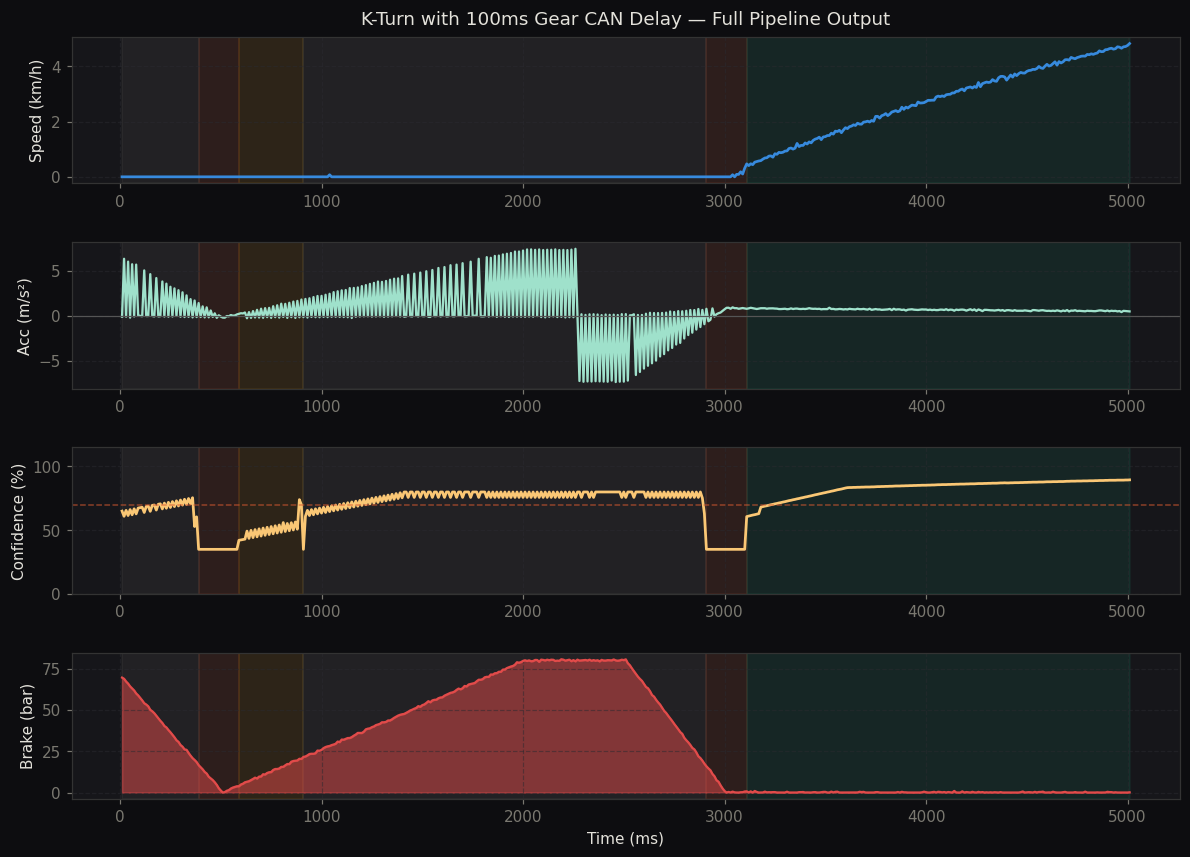

Session summary (501 cycles)
  Forward:      191 (38.1%)
  Reverse:       32 (6.4%)
  Standstill:   238 (47.5%)
  Unknown:       40 (8.0%)
  Confidence: mean=73.3%  min=35.0%
  Events: gear_mismatch=0  wheel_fault=0  transitions=3

Gear mismatch events: 0
  t=390ms  TRANSITION started → UNKNOWN
  t=590ms  TRANSITION completed → REVERSE
  t=910ms  TRANSITION started → STANDSTILL
  t=920ms  TRANSITION completed → STANDSTILL
  t=2910ms  TRANSITION started → UNKNOWN
  t=3110ms  TRANSITION completed → FORWARD


In [ ]:
# ── Simulate a complete K-turn with 100ms gear CAN delay ──────────────────────
model = VehicleModel(noise_seed=42, gear_delay_ms=100)
signals = model.run_manoeuvre(manoeuvre_k_turn())
engine  = DDREngine(debounce_ms=200)
outputs = engine.process_batch(signals)

t_ms    = [s.timestamp_ms for s in signals]
speeds  = [(s.wheel_speeds.fl+s.wheel_speeds.fr+s.wheel_speeds.rl+s.wheel_speeds.rr)/4 for s in signals]
accs    = [s.longitudinal_acceleration for s in signals]
brakes  = [s.brake_pressure_bar for s in signals]
gears   = [s.gear_position.value for s in signals]
dirs    = [o.direction for o in outputs]
confs   = [o.confidence for o in outputs]
gear_mm = [o.diagnostics.gear_mismatch for o in outputs]

fig = plt.figure(figsize=(13, 9))
gs  = GridSpec(4, 1, figure=fig, hspace=0.4)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax4 = fig.add_subplot(gs[3], sharex=ax1)

# Direction background on all axes
for ax in [ax1, ax2, ax3, ax4]:
    prev_d, prev_t = dirs[0], t_ms[0]
    for i in range(1, len(t_ms)):
        if dirs[i] != prev_d or i == len(t_ms)-1:
            ax.axvspan(prev_t, t_ms[i], alpha=0.12, color=DIR_COLOR[prev_d])
            prev_d, prev_t = dirs[i], t_ms[i]

# Speed
ax1.plot(t_ms, speeds, color='#378ADD', linewidth=1.8)
ax1.set_ylabel('Speed (km/h)')
ax1.set_title('K-Turn with 100ms Gear CAN Delay — Full Pipeline Output', pad=8)
ax1.grid(True)

# Acceleration
ax2.plot(t_ms, accs, color='#9FE1CB', linewidth=1.5)
ax2.axhline(0, color='#555', linewidth=0.8)
ax2.set_ylabel('Acc (m/s²)')
ax2.grid(True)

# Confidence + gear mismatch markers
ax3.plot(t_ms, confs, color='#FAC775', linewidth=1.8)
ax3.axhline(70, color='#D85A30', linestyle='--', linewidth=1, alpha=0.6)
mm_times = [t for t, gm in zip(t_ms, gear_mm) if gm]
if mm_times:
    ax3.scatter(mm_times, [105]*len(mm_times), marker='v', color='#D85A30',
                s=20, zorder=5, label='gear_mismatch')
    ax3.legend(fontsize=9)
ax3.set_ylim(0, 115)
ax3.set_ylabel('Confidence (%)')
ax3.grid(True)

# Brake pressure
ax4.fill_between(t_ms, 0, brakes, color='#E24B4A', alpha=0.5)
ax4.plot(t_ms, brakes, color='#E24B4A', linewidth=1.5)
ax4.set_ylabel('Brake (bar)')
ax4.set_xlabel('Time (ms)')
ax4.grid(True)

plt.tight_layout()
plt.show()

summary = SessionSummary.from_outputs(outputs)
print(summary)
print(f"\nGear mismatch events: {summary.gear_mismatch_events}")
events = list(iter_diagnostic_events(outputs))
for t, ev in events[:10]:
    print(f"  t={t:.0f}ms  {ev}")


---
## 9. Run the Algorithm on Your Own Data

You can feed any CSV with vehicle signals into the DDR engine.  
The CSV must have these columns:

| Column | Unit | Notes |
|---|---|---|
| `timestamp_ms` | ms | Monotonically increasing |
| `whl_fl`, `whl_fr`, `whl_rl`, `whl_rr` | km/h | Magnitude only (always ≥ 0) |
| `long_acc_ms2` | m/s² | Positive = forward acceleration |
| `brake_bar` | bar | Master cylinder pressure |
| `gear` | str | P / R / N / D |


In [ ]:
# ── Example: load a CSV and run DDR ──────────────────────────────────────────
# First, generate and save a sample CSV so you can see the format
import io
import csv

model_demo = VehicleModel(noise_seed=7)
demo_signals = model_demo.run_manoeuvre(manoeuvre_city_drive())

# Write to in-memory CSV
buf = io.StringIO()
writer = csv.DictWriter(buf, fieldnames=[
    'timestamp_ms','whl_fl','whl_fr','whl_rl','whl_rr',
    'long_acc_ms2','brake_bar','gear'
])
writer.writeheader()
for s in demo_signals:
    writer.writerow({
        'timestamp_ms': s.timestamp_ms,
        'whl_fl': round(s.wheel_speeds.fl, 2),
        'whl_fr': round(s.wheel_speeds.fr, 2),
        'whl_rl': round(s.wheel_speeds.rl, 2),
        'whl_rr': round(s.wheel_speeds.rr, 2),
        'long_acc_ms2': round(s.longitudinal_acceleration, 3),
        'brake_bar': round(s.brake_pressure_bar, 1),
        'gear': s.gear_position.value,
    })

# Save to disk
with open('sample_city_drive.csv', 'w') as f:
    f.write(buf.getvalue())

print("✅ sample_city_drive.csv written")
print("\nFirst 5 rows:")
buf.seek(0)
for i, line in enumerate(buf.readlines()[:6]):
    print(line.rstrip())


✅ sample_city_drive.csv written

First 5 rows:
timestamp_ms,whl_fl,whl_fr,whl_rl,whl_rr,long_acc_ms2,brake_bar,gear
10.0,0.0,0.0,0.0,0.0,0.107,79.9,D
20.0,0.0,0.0,0.0,0.0,-7.179,77.9,D
30.0,0.0,0.0,0.0,0.0,0.034,76.7,D
40.0,0.0,0.0,0.0,0.0,0.11,75.0,D
50.0,0.0,0.0,0.0,0.0,-6.776,73.6,D


In [ ]:
# ── Load CSV and run DDR ─────────────────────────────────────────────────────
import csv

engine = DDREngine(debounce_ms=200, agree_cycles=3)
outputs = []
signals_loaded = []

with open('sample_city_drive.csv') as f:
    for row in csv.DictReader(f):
        sig = VehicleSignals(
            timestamp_ms=float(row['timestamp_ms']),
            wheel_speeds=WheelSpeeds(
                fl=float(row['whl_fl']), fr=float(row['whl_fr']),
                rl=float(row['whl_rl']), rr=float(row['whl_rr']),
            ),
            gear_position=GearPosition(row['gear']),
            longitudinal_acceleration=float(row['long_acc_ms2']),
            brake_pressure_bar=float(row['brake_bar']),
        )
        signals_loaded.append(sig)
        outputs.append(engine.process(sig))

print(f"Loaded {len(outputs)} cycles from CSV")
print()
print(SessionSummary.from_outputs(outputs))
print()
print("Diagnostic events:")
for t, ev in iter_diagnostic_events(outputs):
    print(f"  t={t:.0f}ms  {ev}")


Loaded 501 cycles from CSV

Session summary (501 cycles)
  Forward:      229 (45.7%)
  Reverse:        0 (0.0%)
  Standstill:   252 (50.3%)
  Unknown:       20 (4.0%)
  Confidence: mean=76.8%  min=35.0%
  Events: gear_mismatch=0  wheel_fault=0  transitions=2

Diagnostic events:
  t=410ms  TRANSITION started → UNKNOWN
  t=610ms  TRANSITION completed → FORWARD
  t=2900ms  TRANSITION started → STANDSTILL
  t=2910ms  TRANSITION completed → STANDSTILL


---
## 10. Quick Reference

### DDROutput fields
```python
output.direction          # DriveDirection: FORWARD / REVERSE / STANDSTILL / UNKNOWN
output.confidence         # float 0–100%
output.time_in_state_ms   # How long in current direction
output.diagnostics        # DiagnosticWord — see below
```

### DiagnosticWord flags
```python
output.diagnostics.gear_mismatch          # Gear CAN contradicts physical sensors
output.diagnostics.wheel_fault            # One+ wheel sensors flagged FAULT
output.diagnostics.low_speed_mode         # Below 0.5 km/h noise floor
output.diagnostics.transition_active      # FSM in 200ms debounce window
output.diagnostics.confidence_degraded    # Confidence below 70%
output.diagnostics.plausibility_conflict  # 2+ checks in disagreement
```

### CAN encoding
```python
from ddr_algorithm.core.diagnostics import encode_diagnostic_word, decode_diagnostic_word
byte = encode_diagnostic_word(output.diagnostics)  # 0x00–0x3F
diag = decode_diagnostic_word(byte)
```

### Engine configuration
```python
engine = DDREngine(
    debounce_ms=200,    # Direction change debounce window
    agree_cycles=3,     # Plausibility cycles before FSM transitions
)
```

### Batch processing
```python
outputs = engine.process_batch(signal_list)
```

### Session summary
```python
from ddr_algorithm.core.diagnostics import SessionSummary
summary = SessionSummary.from_outputs(outputs)
print(summary)  # Prints forward/reverse/standstill breakdown + event counts
```

---

**Further reading:**
- Kiencke & Nielsen, *Automotive Control Systems*, Springer 2005
- Rajamani, *Vehicle Dynamics and Control*, Springer 2012
- ISO 26262-6:2018 — Functional safety: Product development at the software level
- AUTOSAR SWS_StateManager — State management specification

---
*Venay Chawda · github.com/venaychawda/ddr-algorithm*
